In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from simulation import GridWorldEnv, CreateGrid
from algorithm import QLearning, SASAR
from helper import Metrics, get_grid, get_grid_img, create_show_grid

# Intelligente Robotik 
#### WS 2024/25
Julienne Eder, Lea Achter

---

## Dynamische Erstellung der Grid Worlds

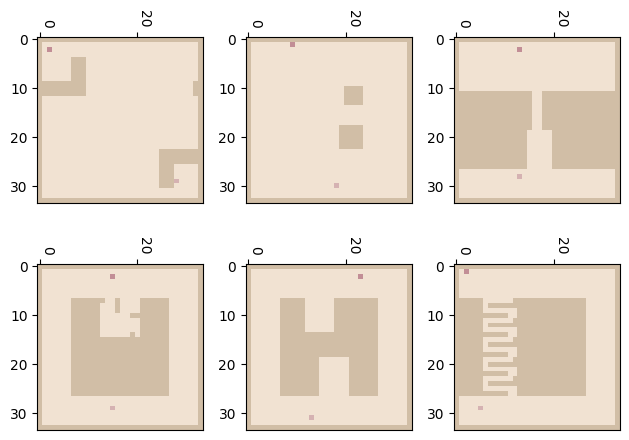

In [3]:
fig, axes = plt.subplots(nrows=2, ncols=3)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

grid_creator = CreateGrid()

star_dict = grid_creator.create_grid('star_grid', 32)
star_data = get_grid_img(star_dict['grid'], (star_dict['agent_x'], star_dict['agent_y']), (star_dict['goal_x'],star_dict['goal_y']))
im = get_grid(star_data, ax=ax1)

simple__dict = grid_creator.create_grid('simple_grid', 32)
simple_data = get_grid_img(simple__dict['grid'], (simple__dict['agent_x'], simple__dict['agent_y']), (simple__dict['goal_x'] ,simple__dict['goal_y']))
im = get_grid(simple_data, ax=ax2)

bottleneck_dict = grid_creator.create_grid('bottleneck_grid', 32)
bottleneck_data = get_grid_img(bottleneck_dict['grid'], (bottleneck_dict['agent_x'], bottleneck_dict['agent_y']), (bottleneck_dict['goal_x'],bottleneck_dict['goal_y']))
im = get_grid(bottleneck_data, ax=ax3)

trap_dict = grid_creator.create_grid('trap_grid', 32)
trap_data = get_grid_img(trap_dict['grid'], (trap_dict['agent_x'], trap_dict['agent_y']), (trap_dict['goal_x'],trap_dict['goal_y']))
im = get_grid(trap_data, ax=ax4)

doubletrap_dict = grid_creator.create_grid('doubletrap_grid', 32)
doubletrap_data = get_grid_img(doubletrap_dict['grid'], (doubletrap_dict['agent_x'], doubletrap_dict['agent_y']), (doubletrap_dict['goal_x'],doubletrap_dict['goal_y']))
im = get_grid(doubletrap_data, ax=ax5)

detour_dict = grid_creator.create_grid('detour_grid', 32)
detour_data = get_grid_img(detour_dict['grid'], (detour_dict['agent_x'], detour_dict['agent_y']), (detour_dict['goal_x'],detour_dict['goal_y']))
im = get_grid(detour_data, ax=ax6)

fig.tight_layout()
plt.show()


Grids können durch einen Größenparameter dynamisch angepasst werden. Allgemein herrschen folgende Bedingungen:

- 2D-Umwelt
- statische Umgebung 
- Hindernisse sind a priori bekannt
- Umgebung: ein Roboter
- mobiler Roboter
- Objektform fest
- Hindernisse durch Roboter nicht bewegbar
- Roboterbewegung eingeschränkt (4 Himmelsrichtungen)
- Grids ändern den Standort des Agenten und Zielpunktes bzw. den Standort der Hindernisse

## Algorithmen

| |  A* (manhattan) | Wavefront (BFS)  | MITM (BFS) | Q-Learning| SASAR|
|:------------- |:------------- |:---------------:| -------------:| -------------:|-------------:|
| Speicherkomplexität | O(n)         | O(rows * cols)|O(rows * cols)|O(n_states * action_space)| O(n_states * action_space)| 
| Laufzeitkomplexität | O(n^2 log n)  |O(rows * cols)|O(rows * cols)| O(episodes * max_steps * action_space)| O(episodes * max_steps * action_space)| 
| Echtzeit (E) / Anytime (A)| E   | E | E | A | A | 
| Ausführungszeit (avg_empty_64) | 0.05538 ± 0.04596 | 0.00508 ± 0.00033 | 0.00395 ± 0.00090 | - |  -| 
| Steps bis Konvergenz (avg_empty_64)| 1752.20000 ± 983.96553   | 3197.20000 ± 225.06035   | 2306.20000 ± 297.81095 | - | - | 
| Durchschnittliche Pfadlänge (avg_empty_64)| 65.40000 ± 7.88923 |    63.00000 ± 6.78233    |63.20000 ± 6.91086| - | -| 


\
\
Meet-in-the-middle (MITM) \
breadth-first search (BFS) 

### A* Algorithmus

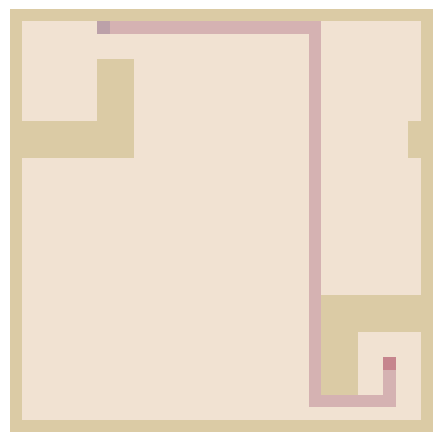

In [4]:
# show example grid

data = create_show_grid(algorithm='A-star', grid='star_grid')
fig, ax = plt.subplots()
im = get_grid(data, ax=ax)
fig.tight_layout()
plt.axis('off')
plt.show()

In [5]:
# get metrics 
size_grid = 16
num_runs = 5

metrics = Metrics()
df_astar_16 = metrics.get_metrics(algorithm='A-star', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des A*-Algorithmus mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_astar_16



Metriken des A*-Algorithmus mit einer Gridgröße von 16 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00031 ± 0.00017,17.00000 ± 1.41421,157.00000 ± 84.35876,13.65148 ± 0.14425
1,star_grid,0.00204 ± 0.00003,30.20000 ± 0.74833,903.00000 ± 294.15642,13.79872 ± 0.03997
2,simple_grid,0.00018 ± 0.00008,16.00000 ± 1.41421,1443.20000 ± 61.26794,12.77165 ± 0.49889
3,bottleneck_grid,0.00013 ± 0.00004,18.00000 ± 2.00000,1643.80000 ± 53.24059,10.37283 ± 0.27533
4,trap_grid,0.00026 ± 0.00006,22.20000 ± 1.72047,1890.40000 ± 89.39485,11.53399 ± 0.20400
5,doubletrap_grid,0.00024 ± 0.00006,22.80000 ± 1.83303,2175.00000 ± 81.39779,11.33903 ± 0.13948
6,detour_grid,0.00007 ± 0.00001,18.00000 ± 1.26491,2368.00000 ± 35.95553,11.21800 ± 0.17008
7,all,0.00046 ± 0.00065,20.60000 ± 4.83558,1511.48571 ± 723.15212,12.09796 ± 1.24450


In [6]:
# get metrics 
size_grid = 32
num_runs = 5

metrics = Metrics()
df_astar_32 = metrics.get_metrics(algorithm='A-star', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des A*-Algorithmus mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_astar_32



Metriken des A*-Algorithmus mit einer Gridgröße von 32 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00235 ± 0.00263,32.60000 ± 4.40908,387.60000 ± 261.02383,26.27486 ± 0.33924
1,star_grid,0.02132 ± 0.00155,57.60000 ± 1.62481,2967.60000 ± 1043.73284,25.86765 ± 0.11834
2,simple_grid,0.00117 ± 0.00058,32.00000 ± 2.19089,4821.60000 ± 202.84536,22.00926 ± 0.86101
3,bottleneck_grid,0.00104 ± 0.00085,35.20000 ± 5.11468,5424.20000 ± 198.28908,19.49241 ± 0.52594
4,trap_grid,0.00187 ± 0.00038,43.00000 ± 1.41421,6330.00000 ± 288.21520,20.91294 ± 0.55897
5,doubletrap_grid,0.00168 ± 0.00039,43.40000 ± 2.41661,7265.80000 ± 256.08936,21.02377 ± 0.44403
6,detour_grid,0.00472 ± 0.00067,75.20000 ± 2.22711,8650.40000 ± 464.27130,21.38881 ± 0.12243
7,all,0.00488 ± 0.00693,45.57143 ± 14.92703,5121.02857 ± 2600.67201,22.42424 ± 2.46232


In [7]:
# get metrics 
size_grid = 64
num_runs = 5

metrics = Metrics()
df_astar_64 = metrics.get_metrics(algorithm='A-star', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des A*-Algorithmus mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_astar_64



Metriken des A*-Algorithmus mit einer Gridgröße von 64 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.02914 ± 0.03763,66.20000 ± 10.49571,2185.20000 ± 1075.06658,52.07770 ± 1.04232
1,star_grid,0.21364 ± 0.03785,112.00000 ± 4.28952,10793.20000 ± 3432.24250,49.03406 ± 0.46737
2,simple_grid,0.01607 ± 0.01129,67.60000 ± 6.11882,17325.80000 ± 642.51705,41.64903 ± 3.52853
3,bottleneck_grid,0.01043 ± 0.00306,69.20000 ± 2.99333,19812.20000 ± 701.06759,36.46180 ± 0.77357
4,trap_grid,0.02189 ± 0.00467,87.60000 ± 5.42586,22989.80000 ± 1084.96109,38.54873 ± 0.56631
5,doubletrap_grid,0.02372 ± 0.00624,91.20000 ± 4.83322,26878.80000 ± 1075.74744,39.56026 ± 1.43684
6,detour_grid,0.04955 ± 0.00414,147.20000 ± 1.46969,31863.60000 ± 1645.47605,40.44270 ± 0.07576
7,all,0.05206 ± 0.07015,91.57143 ± 27.97068,18835.51429 ± 9378.62947,42.53919 ± 5.56560


### Wavefront

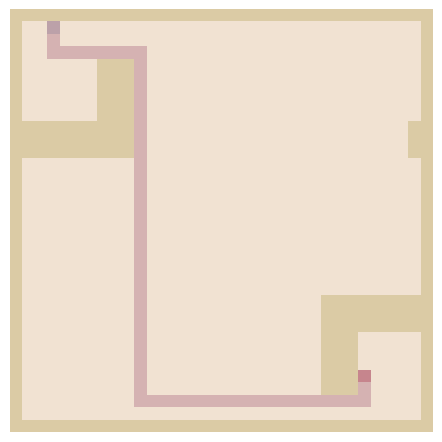

In [8]:
# show example grid

data = create_show_grid(algorithm='Wavefront', grid='star_grid')
fig, ax = plt.subplots()
im = get_grid(data, ax=ax)
fig.tight_layout()
plt.axis('off')
plt.show()

In [9]:
# get metrics 
size_grid = 16
num_runs = 5

metrics = Metrics()
df_wf_16 = metrics.get_metrics(algorithm='Wavefront', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des Wavefront mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_wf_16



Metriken des Wavefront mit einer Gridgröße von 16 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00015 ± 0.00003,16.80000 ± 2.48193,194.80000 ± 32.48015,13.48709 ± 0.13685
1,star_grid,0.00016 ± 0.00000,31.20000 ± 1.60000,234.00000 ± 0.00000,13.84842 ± 0.08437
2,simple_grid,0.00011 ± 0.00001,15.60000 ± 1.01980,167.20000 ± 16.50939,13.13571 ± 0.23258
3,bottleneck_grid,0.00007 ± 0.00000,18.60000 ± 1.85472,106.80000 ± 8.18291,10.43629 ± 0.09220
4,trap_grid,0.00010 ± 0.00000,23.20000 ± 1.32665,153.80000 ± 8.23165,11.32569 ± 0.11172
5,doubletrap_grid,0.00010 ± 0.00001,22.80000 ± 2.40000,146.60000 ± 20.16532,11.39173 ± 0.05915
6,detour_grid,0.00006 ± 0.00000,18.60000 ± 1.20000,88.20000 ± 6.64530,11.33133 ± 0.18211
7,all,0.00011 ± 0.00004,20.97143 ± 5.24533,155.91429 ± 48.90011,12.13661 ± 1.23299


In [10]:
# get metrics 
size_grid = 32
num_runs = 5

metrics = Metrics()
df_wf_32 = metrics.get_metrics(algorithm='Wavefront', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des Wavefront mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_wf_32



Metriken des Wavefront mit einer Gridgröße von 32 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00059 ± 0.00013,31.80000 ± 3.70945,753.80000 ± 82.23235,26.25792 ± 0.50448
1,star_grid,0.00061 ± 0.00001,56.60000 ± 2.57682,917.80000 ± 5.87878,25.79434 ± 0.14289
2,simple_grid,0.00045 ± 0.00005,32.40000 ± 4.63033,678.80000 ± 81.76894,23.16423 ± 0.81331
3,bottleneck_grid,0.00028 ± 0.00001,35.60000 ± 3.26190,415.00000 ± 20.46460,19.13195 ± 0.34360
4,trap_grid,0.00039 ± 0.00002,44.20000 ± 1.46969,595.20000 ± 34.15494,20.96336 ± 0.48251
5,doubletrap_grid,0.00040 ± 0.00005,43.60000 ± 3.00666,601.40000 ± 79.16716,21.21757 ± 0.40658
6,detour_grid,0.00037 ± 0.00001,74.40000 ± 1.85472,564.00000 ± 10.39230,22.01628 ± 0.33469
7,all,0.00044 ± 0.00012,45.51429 ± 14.58056,646.57143 ± 157.05691,22.64938 ± 2.46135


In [11]:
# get metrics 
size_grid = 64
num_runs = 5

metrics = Metrics()
df_wf_64 = metrics.get_metrics(algorithm='Wavefront', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des Wavefront mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_wf_64



Metriken des Wavefront mit einer Gridgröße von 64 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00226 ± 0.00026,65.20000 ± 1.72047,3235.00000 ± 121.88519,51.83799 ± 0.48190
1,star_grid,0.00247 ± 0.00007,112.60000 ± 3.00666,3658.80000 ± 17.26731,49.56459 ± 0.47411
2,simple_grid,0.00207 ± 0.00015,65.80000 ± 4.83322,3119.00000 ± 244.01967,38.42836 ± 1.78635
3,bottleneck_grid,0.00117 ± 0.00009,67.40000 ± 8.13880,1716.60000 ± 84.51887,36.65030 ± 0.65130
4,trap_grid,0.00164 ± 0.00009,90.20000 ± 7.02567,2498.00000 ± 152.62765,39.52604 ± 0.98410
5,doubletrap_grid,0.00171 ± 0.00009,93.00000 ± 5.21536,2581.20000 ± 164.36715,39.75733 ± 0.27867
6,detour_grid,0.00138 ± 0.00001,148.40000 ± 3.72022,2098.60000 ± 24.51612,42.92320 ± 0.41871
7,all,0.00181 ± 0.00046,91.80000 ± 28.81250,2701.02857 ± 643.37359,42.66969 ± 5.47125


### Meet-in-the-Middle

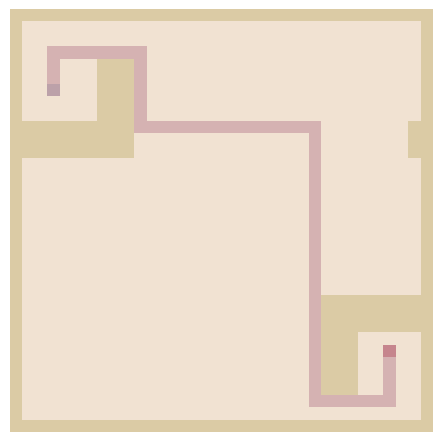

In [12]:
# show example grid

data = create_show_grid(algorithm='MITM', grid='star_grid')
fig, ax = plt.subplots()
im = get_grid(data, ax=ax)
fig.tight_layout()
plt.axis('off')
plt.show()

In [13]:
# get metrics 
size_grid = 16
num_runs = 5

metrics = Metrics()
df_mitm_16 = metrics.get_metrics(algorithm='MITM', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des MITM mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_mitm_16



Metriken des MITM mit einer Gridgröße von 16 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00013 ± 0.00004,17.00000 ± 2.19089,127.60000 ± 31.66449,13.42117 ± 0.16924
1,star_grid,0.00013 ± 0.00002,30.20000 ± 1.16619,168.00000 ± 0.00000,13.35495 ± 0.06138
2,simple_grid,0.00011 ± 0.00002,16.40000 ± 2.15407,115.60000 ± 22.90502,12.44401 ± 0.44016
3,bottleneck_grid,0.00007 ± 0.00000,19.00000 ± 2.19089,99.20000 ± 6.76461,10.29742 ± 0.13515
4,trap_grid,0.00009 ± 0.00001,22.20000 ± 1.60000,123.80000 ± 9.60000,11.28819 ± 0.09075
5,doubletrap_grid,0.00009 ± 0.00002,21.40000 ± 3.00666,126.40000 ± 25.27924,11.48474 ± 0.12807
6,detour_grid,0.00006 ± 0.00001,19.40000 ± 0.80000,67.20000 ± 1.60000,11.42219 ± 0.11226
7,all,0.00010 ± 0.00003,20.80000 ± 4.74372,118.25714 ± 33.68454,11.95895 ± 1.09070


In [14]:
# get metrics 
size_grid = 32
num_runs = 5

metrics = Metrics()
df_mitm_32 = metrics.get_metrics(algorithm='MITM', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des MITM mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_mitm_32



Metriken des MITM mit einer Gridgröße von 32 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00041 ± 0.00005,31.80000 ± 2.03961,526.00000 ± 77.28389,25.99738 ± 0.17543
1,star_grid,0.00048 ± 0.00002,57.80000 ± 2.56125,708.00000 ± 0.00000,24.97149 ± 0.14141
2,simple_grid,0.00036 ± 0.00003,33.00000 ± 1.78885,521.00000 ± 38.98718,21.69868 ± 0.99174
3,bottleneck_grid,0.00031 ± 0.00006,34.20000 ± 2.92575,422.80000 ± 23.82771,18.66056 ± 0.18018
4,trap_grid,0.00040 ± 0.00008,45.80000 ± 3.18748,555.00000 ± 46.65619,20.18319 ± 0.18883
5,doubletrap_grid,0.00039 ± 0.00004,44.20000 ± 3.81576,588.40000 ± 66.31018,20.64944 ± 0.20073
6,detour_grid,0.00036 ± 0.00003,74.00000 ± 2.00000,529.00000 ± 0.00000,21.34239 ± 0.13088
7,all,0.00039 ± 0.00007,45.82857 ± 14.57686,550.02857 ± 91.91284,21.92902 ± 2.47078


In [15]:
# get metrics 
size_grid = 64
num_runs = 5

metrics = Metrics()
df_mitm_64 = metrics.get_metrics(algorithm='MITM', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des MITM mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df_mitm_64



Metriken des MITM mit einer Gridgröße von 64 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge,avg_distance
0,empty,0.00175 ± 0.00027,69.60000 ± 4.58694,2439.20000 ± 306.78553,51.23870 ± 0.31356
1,star_grid,0.00210 ± 0.00021,108.00000 ± 3.74166,2984.80000 ± 8.61162,47.11349 ± 0.24843
2,simple_grid,0.00136 ± 0.00016,65.80000 ± 2.92575,2135.20000 ± 261.80710,40.54500 ± 1.42610
3,bottleneck_grid,0.00105 ± 0.00008,64.80000 ± 7.05408,1633.80000 ± 117.61701,35.57906 ± 0.68254
4,trap_grid,0.00153 ± 0.00031,84.00000 ± 10.17841,2068.40000 ± 296.37719,38.37093 ± 0.50631
5,doubletrap_grid,0.00142 ± 0.00021,82.80000 ± 7.80769,2109.80000 ± 231.57496,38.39091 ± 0.25246
6,detour_grid,0.00131 ± 0.00001,148.00000 ± 5.93296,1999.00000 ± 0.00000,40.52186 ± 0.34356
7,all,0.00150 ± 0.00037,89.00000 ± 28.53269,2195.74286 ± 444.27671,41.67999 ± 5.14932


#### Überblick Algorithmen

In [16]:
# avg_time
column_names = ['benchmark', 'astar_16', 'astar_32', 'astar_64', 
                'wavefront_16', 'wavefront_32', 'wavefront_64',
                'mitm_16', 'mitm_32', 'mitm_64']

df_avg_time = pd.concat([df_astar_16.iloc[:,:2], df_astar_32.iloc[:,1], df_astar_64.iloc[:,1], 
                         df_wf_16.iloc[:,1], df_wf_32.iloc[:,1], df_wf_64.iloc[:,1],
                         df_mitm_16.iloc[:,1], df_mitm_32.iloc[:,1], df_mitm_64.iloc[:,1]
                        ], axis=1)
df_avg_time.columns=column_names
print('\n\nDurchschnittliche Zeit die benötigt wurde um den Pfad zu finden:\n')
df_avg_time



Durchschnittliche Zeit die benötigt wurde um den Pfad zu finden:



,benchmark,astar_16,astar_32,astar_64,wavefront_16,wavefront_32,wavefront_64,mitm_16,mitm_32,mitm_64
0,empty,0.00031 ± 0.00017,0.00235 ± 0.00263,0.02914 ± 0.03763,0.00015 ± 0.00003,0.00059 ± 0.00013,0.00226 ± 0.00026,0.00013 ± 0.00004,0.00041 ± 0.00005,0.00175 ± 0.00027
1,star_grid,0.00204 ± 0.00003,0.02132 ± 0.00155,0.21364 ± 0.03785,0.00016 ± 0.00000,0.00061 ± 0.00001,0.00247 ± 0.00007,0.00013 ± 0.00002,0.00048 ± 0.00002,0.00210 ± 0.00021
2,simple_grid,0.00018 ± 0.00008,0.00117 ± 0.00058,0.01607 ± 0.01129,0.00011 ± 0.00001,0.00045 ± 0.00005,0.00207 ± 0.00015,0.00011 ± 0.00002,0.00036 ± 0.00003,0.00136 ± 0.00016
3,bottleneck_grid,0.00013 ± 0.00004,0.00104 ± 0.00085,0.01043 ± 0.00306,0.00007 ± 0.00000,0.00028 ± 0.00001,0.00117 ± 0.00009,0.00007 ± 0.00000,0.00031 ± 0.00006,0.00105 ± 0.00008
4,trap_grid,0.00026 ± 0.00006,0.00187 ± 0.00038,0.02189 ± 0.00467,0.00010 ± 0.00000,0.00039 ± 0.00002,0.00164 ± 0.00009,0.00009 ± 0.00001,0.00040 ± 0.00008,0.00153 ± 0.00031
5,doubletrap_grid,0.00024 ± 0.00006,0.00168 ± 0.00039,0.02372 ± 0.00624,0.00010 ± 0.00001,0.00040 ± 0.00005,0.00171 ± 0.00009,0.00009 ± 0.00002,0.00039 ± 0.00004,0.00142 ± 0.00021
6,detour_grid,0.00007 ± 0.00001,0.00472 ± 0.00067,0.04955 ± 0.00414,0.00006 ± 0.00000,0.00037 ± 0.00001,0.00138 ± 0.00001,0.00006 ± 0.00001,0.00036 ± 0.00003,0.00131 ± 0.00001
7,all,0.00046 ± 0.00065,0.00488 ± 0.00693,0.05206 ± 0.07015,0.00011 ± 0.00004,0.00044 ± 0.00012,0.00181 ± 0.00046,0.00010 ± 0.00003,0.00039 ± 0.00007,0.00150 ± 0.00037


In [17]:
# avg_path_length

df_avg_path = pd.concat([df_astar_16.iloc[:,0], df_astar_16.iloc[:,2], df_astar_32.iloc[:,2], df_astar_64.iloc[:,2], 
                         df_wf_16.iloc[:,2], df_wf_32.iloc[:,2], df_wf_64.iloc[:,2],
                         df_mitm_16.iloc[:,2], df_mitm_32.iloc[:,2], df_mitm_64.iloc[:,2]
                        ], axis=1)
df_avg_path.columns=column_names
print('\n\nDurchschnittliche Pfadlänge:\n')
df_avg_path



Durchschnittliche Pfadlänge:



,benchmark,astar_16,astar_32,astar_64,wavefront_16,wavefront_32,wavefront_64,mitm_16,mitm_32,mitm_64
0,empty,17.00000 ± 1.41421,32.60000 ± 4.40908,66.20000 ± 10.49571,16.80000 ± 2.48193,31.80000 ± 3.70945,65.20000 ± 1.72047,17.00000 ± 2.19089,31.80000 ± 2.03961,69.60000 ± 4.58694
1,star_grid,30.20000 ± 0.74833,57.60000 ± 1.62481,112.00000 ± 4.28952,31.20000 ± 1.60000,56.60000 ± 2.57682,112.60000 ± 3.00666,30.20000 ± 1.16619,57.80000 ± 2.56125,108.00000 ± 3.74166
2,simple_grid,16.00000 ± 1.41421,32.00000 ± 2.19089,67.60000 ± 6.11882,15.60000 ± 1.01980,32.40000 ± 4.63033,65.80000 ± 4.83322,16.40000 ± 2.15407,33.00000 ± 1.78885,65.80000 ± 2.92575
3,bottleneck_grid,18.00000 ± 2.00000,35.20000 ± 5.11468,69.20000 ± 2.99333,18.60000 ± 1.85472,35.60000 ± 3.26190,67.40000 ± 8.13880,19.00000 ± 2.19089,34.20000 ± 2.92575,64.80000 ± 7.05408
4,trap_grid,22.20000 ± 1.72047,43.00000 ± 1.41421,87.60000 ± 5.42586,23.20000 ± 1.32665,44.20000 ± 1.46969,90.20000 ± 7.02567,22.20000 ± 1.60000,45.80000 ± 3.18748,84.00000 ± 10.17841
5,doubletrap_grid,22.80000 ± 1.83303,43.40000 ± 2.41661,91.20000 ± 4.83322,22.80000 ± 2.40000,43.60000 ± 3.00666,93.00000 ± 5.21536,21.40000 ± 3.00666,44.20000 ± 3.81576,82.80000 ± 7.80769
6,detour_grid,18.00000 ± 1.26491,75.20000 ± 2.22711,147.20000 ± 1.46969,18.60000 ± 1.20000,74.40000 ± 1.85472,148.40000 ± 3.72022,19.40000 ± 0.80000,74.00000 ± 2.00000,148.00000 ± 5.93296
7,all,20.60000 ± 4.83558,45.57143 ± 14.92703,91.57143 ± 27.97068,20.97143 ± 5.24533,45.51429 ± 14.58056,91.80000 ± 28.81250,20.80000 ± 4.74372,45.82857 ± 14.57686,89.00000 ± 28.53269


In [18]:
# avg_steps_to_converge 	

df_avg_step = pd.concat([df_astar_16.iloc[:,0], df_astar_16.iloc[:,3], df_astar_32.iloc[:,3], df_astar_64.iloc[:,3], 
                         df_wf_16.iloc[:,3], df_wf_32.iloc[:,3], df_wf_64.iloc[:,3],
                         df_mitm_16.iloc[:,3], df_mitm_32.iloc[:,3], df_mitm_64.iloc[:,3]
                        ], axis=1)
df_avg_step.columns=column_names
print('\n\nDurchschnittliche Anzahl der Knoten die betrachtet werden müssen bis Konvergenz:\n')
df_avg_step



Durchschnittliche Anzahl der Knoten die betrachtet werden müssen bis Konvergenz:



,benchmark,astar_16,astar_32,astar_64,wavefront_16,wavefront_32,wavefront_64,mitm_16,mitm_32,mitm_64
0,empty,157.00000 ± 84.35876,387.60000 ± 261.02383,2185.20000 ± 1075.06658,194.80000 ± 32.48015,753.80000 ± 82.23235,3235.00000 ± 121.88519,127.60000 ± 31.66449,526.00000 ± 77.28389,2439.20000 ± 306.78553
1,star_grid,903.00000 ± 294.15642,2967.60000 ± 1043.73284,10793.20000 ± 3432.24250,234.00000 ± 0.00000,917.80000 ± 5.87878,3658.80000 ± 17.26731,168.00000 ± 0.00000,708.00000 ± 0.00000,2984.80000 ± 8.61162
2,simple_grid,1443.20000 ± 61.26794,4821.60000 ± 202.84536,17325.80000 ± 642.51705,167.20000 ± 16.50939,678.80000 ± 81.76894,3119.00000 ± 244.01967,115.60000 ± 22.90502,521.00000 ± 38.98718,2135.20000 ± 261.80710
3,bottleneck_grid,1643.80000 ± 53.24059,5424.20000 ± 198.28908,19812.20000 ± 701.06759,106.80000 ± 8.18291,415.00000 ± 20.46460,1716.60000 ± 84.51887,99.20000 ± 6.76461,422.80000 ± 23.82771,1633.80000 ± 117.61701
4,trap_grid,1890.40000 ± 89.39485,6330.00000 ± 288.21520,22989.80000 ± 1084.96109,153.80000 ± 8.23165,595.20000 ± 34.15494,2498.00000 ± 152.62765,123.80000 ± 9.60000,555.00000 ± 46.65619,2068.40000 ± 296.37719
5,doubletrap_grid,2175.00000 ± 81.39779,7265.80000 ± 256.08936,26878.80000 ± 1075.74744,146.60000 ± 20.16532,601.40000 ± 79.16716,2581.20000 ± 164.36715,126.40000 ± 25.27924,588.40000 ± 66.31018,2109.80000 ± 231.57496
6,detour_grid,2368.00000 ± 35.95553,8650.40000 ± 464.27130,31863.60000 ± 1645.47605,88.20000 ± 6.64530,564.00000 ± 10.39230,2098.60000 ± 24.51612,67.20000 ± 1.60000,529.00000 ± 0.00000,1999.00000 ± 0.00000
7,all,1511.48571 ± 723.15212,5121.02857 ± 2600.67201,18835.51429 ± 9378.62947,155.91429 ± 48.90011,646.57143 ± 157.05691,2701.02857 ± 643.37359,118.25714 ± 33.68454,550.02857 ± 91.91284,2195.74286 ± 444.27671


In [19]:
# avg_distance

df_avg_dist = pd.concat([df_astar_16.iloc[:,0], df_astar_16.iloc[:,4], df_astar_32.iloc[:,4], df_astar_64.iloc[:,4], 
                         df_wf_16.iloc[:,4], df_wf_32.iloc[:,4], df_wf_64.iloc[:,4],
                         df_mitm_16.iloc[:,4], df_mitm_32.iloc[:,4], df_mitm_64.iloc[:,4]
                        ], axis=1)
df_avg_dist.columns=column_names
print('\n\nDurchschnittliche Distanz zu Hindernissen:\n')
df_avg_dist



Durchschnittliche Distanz zu Hindernissen:



,benchmark,astar_16,astar_32,astar_64,wavefront_16,wavefront_32,wavefront_64,mitm_16,mitm_32,mitm_64
0,empty,13.65148 ± 0.14425,26.27486 ± 0.33924,52.07770 ± 1.04232,13.48709 ± 0.13685,26.25792 ± 0.50448,51.83799 ± 0.48190,13.42117 ± 0.16924,25.99738 ± 0.17543,51.23870 ± 0.31356
1,star_grid,13.79872 ± 0.03997,25.86765 ± 0.11834,49.03406 ± 0.46737,13.84842 ± 0.08437,25.79434 ± 0.14289,49.56459 ± 0.47411,13.35495 ± 0.06138,24.97149 ± 0.14141,47.11349 ± 0.24843
2,simple_grid,12.77165 ± 0.49889,22.00926 ± 0.86101,41.64903 ± 3.52853,13.13571 ± 0.23258,23.16423 ± 0.81331,38.42836 ± 1.78635,12.44401 ± 0.44016,21.69868 ± 0.99174,40.54500 ± 1.42610
3,bottleneck_grid,10.37283 ± 0.27533,19.49241 ± 0.52594,36.46180 ± 0.77357,10.43629 ± 0.09220,19.13195 ± 0.34360,36.65030 ± 0.65130,10.29742 ± 0.13515,18.66056 ± 0.18018,35.57906 ± 0.68254
4,trap_grid,11.53399 ± 0.20400,20.91294 ± 0.55897,38.54873 ± 0.56631,11.32569 ± 0.11172,20.96336 ± 0.48251,39.52604 ± 0.98410,11.28819 ± 0.09075,20.18319 ± 0.18883,38.37093 ± 0.50631
5,doubletrap_grid,11.33903 ± 0.13948,21.02377 ± 0.44403,39.56026 ± 1.43684,11.39173 ± 0.05915,21.21757 ± 0.40658,39.75733 ± 0.27867,11.48474 ± 0.12807,20.64944 ± 0.20073,38.39091 ± 0.25246
6,detour_grid,11.21800 ± 0.17008,21.38881 ± 0.12243,40.44270 ± 0.07576,11.33133 ± 0.18211,22.01628 ± 0.33469,42.92320 ± 0.41871,11.42219 ± 0.11226,21.34239 ± 0.13088,40.52186 ± 0.34356
7,all,12.09796 ± 1.24450,22.42424 ± 2.46232,42.53919 ± 5.56560,12.13661 ± 1.23299,22.64938 ± 2.46135,42.66969 ± 5.47125,11.95895 ± 1.09070,21.92902 ± 2.47078,41.67999 ± 5.14932


## Reinforcement Learning

In [20]:
# Training parameters
n_training_episodes = 10000
learning_rate = 0.7        

# Exploration parameters
max_epsilon = 1.0           
min_epsilon = 0.05           
decay_rate = 0.0005      

### Q-Learning

Update Q-Table with:

$$
  Q(s,a) \leftarrow Q(s,a) + \alpha [R + \gamma  max_aQ(s', a) - Q(s,a)]
$$

Beispiel:

In [21]:
# show example Q-Table 

grid_creator = CreateGrid()
grid_dict = grid_creator.create_grid('star_grid', 16)

env = GridWorldEnv(render_mode="rgb_array", map_dict=grid_dict)
agent = QLearning(env)

# Environment parameters
max_steps =  agent.n_states * 2          
gamma = 0.95               

q_table_ql = agent.train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, max_steps, learning_rate, gamma)


  0%|          | 0/10000 [00:00<?, ?it/s]

In [22]:
env = GridWorldEnv(render_mode="human", map_dict=grid_dict)

# take always the best option
observation, info = env.reset()
state = agent.get_state(observation['agent'])
episode_over = False
while not episode_over:
    
    action = agent.greedy_policy(state)
    observation, reward, terminated, truncated, info = env.step(action)
    state = agent.get_state(observation['agent'])
    episode_over = terminated or truncated

env.close()


In [25]:
# get metrics

metrics = Metrics()
df_qlearning  = metrics.get_rl_metrics(algorithm='qlearning')

  0%|          | 0/500 [00:00<?, ?it/s]

/home/lea/Dokumente/WS24_25/Robotik_projekt/helper/metrics.py:150: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measurements = pd.concat([measurements, row], ignore_index=True)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [26]:
df_qlearning

,benchmark,train_epoch,avg_time_train (sec),mean_reward,std_reward
0,empty,500,5.665499,72.0,0.0
1,empty,1000,6.446173,67.0,0.0
2,empty,10000,13.898457,64.0,0.0
3,star_grid,500,10.307864,43.0,0.0
4,star_grid,1000,12.705460,44.0,0.0
5,star_grid,10000,25.797311,44.0,0.0
6,simple_grid,500,6.401319,66.0,0.0
7,simple_grid,1000,7.855619,64.0,0.0
8,simple_grid,10000,12.709558,73.0,0.0
9,bottleneck_grid,500,12.433643,67.0,0.0


### SASAR

Update Q-Table with:

$$
  Q(s,a) \leftarrow Q(s,a) + \alpha [R + \gamma * Q(s', a') - Q(s,a)]
$$

Beispiel:

In [27]:
 
grid_creator = CreateGrid()
grid_dict = grid_creator.create_grid('star_grid', 16)

env = GridWorldEnv(render_mode="rgb_array", map_dict=grid_dict)
agent = SASAR(env)

# Environment parameters
max_steps =  agent.n_states * 2          
gamma = 0.95               

q_table_sasar = agent.train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, max_steps, learning_rate, gamma)


  0%|          | 0/10000 [00:00<?, ?it/s]

In [28]:
env = GridWorldEnv(render_mode="human", map_dict=grid_dict)

# take always the best option
observation, info = env.reset()
state = agent.get_state(observation['agent'])
episode_over = False
while not episode_over:
    
    action = agent.greedy_policy(state)
    observation, reward, terminated, truncated, info = env.step(action)
    state = agent.get_state(observation['agent'])
    episode_over = terminated or truncated

env.close()


In [ ]:
# get metrics
metrics = Metrics()
df_sasar  = metrics.get_rl_metrics(algorithm='sasar')

  0%|          | 0/500 [00:00<?, ?it/s]

/home/lea/Dokumente/WS24_25/Robotik_projekt/helper/metrics.py:150: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measurements = pd.concat([measurements, row], ignore_index=True)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
df_sasar